<h3 align="center">Task N1 - NN training with torch</h3>

- **Fully connected neural networks** are the foundation of deep learning models. Able to learn any function they are powerful estimators. While it's easy to build and train neural network, debugging it becomes harder and harder more complex the network becomes. Forward and backward pass might run but there could be some other mathematical error which keeps network from learning.

- To get the dataset use the code below:
```
import pandas as pd
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
data = pd.read_csv(url, header=None, names=col_names)
```

- Your task is to train a binary classification network with binary cross entropy loss for predicting diabetes. Train your network with torch and with pytorch-lightning, explain your findings, reason around the network's performance, try different hyperparameters/network architecture setups

In [3]:
!pip install torch

In [4]:
!pip install pytorch-lightning

Import all the necessary libraries.

In [5]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image

Let's follow the instructions to read the data.

In [6]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
data = pd.read_csv(url, header=None, names=col_names)

In [7]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [8]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Before starting data processing and EDA, it's always helpful to gather a little expert knowledge to work with the data correctly. For instance, some feature values cannot be zero. Therefore, in the 'Glucose,' 'BloodPressure,' 'Insulin,' and 'BMI' columns, I will replace zero values by NaNs.

In [9]:
data[['Glucose', 'BloodPressure', 'Insulin', 'BMI']] = data[['Glucose', 'BloodPressure', 'Insulin', 'BMI']].replace(0, np.nan)

Remove all duplicate rows if any

In [10]:
data.drop_duplicates()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29,NaN,26.6,0.351,31,0
2,8,183.0,64.0,0,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23,112.0,26.2,0.245,30,0
766,1,126.0,60.0,0,NaN,30.1,0.349,47,1


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


Let's plot the distributions of these features to determine the best approach for filling the missing values.

In [12]:
features = ['Glucose', 'BloodPressure', 'Insulin', 'BMI']

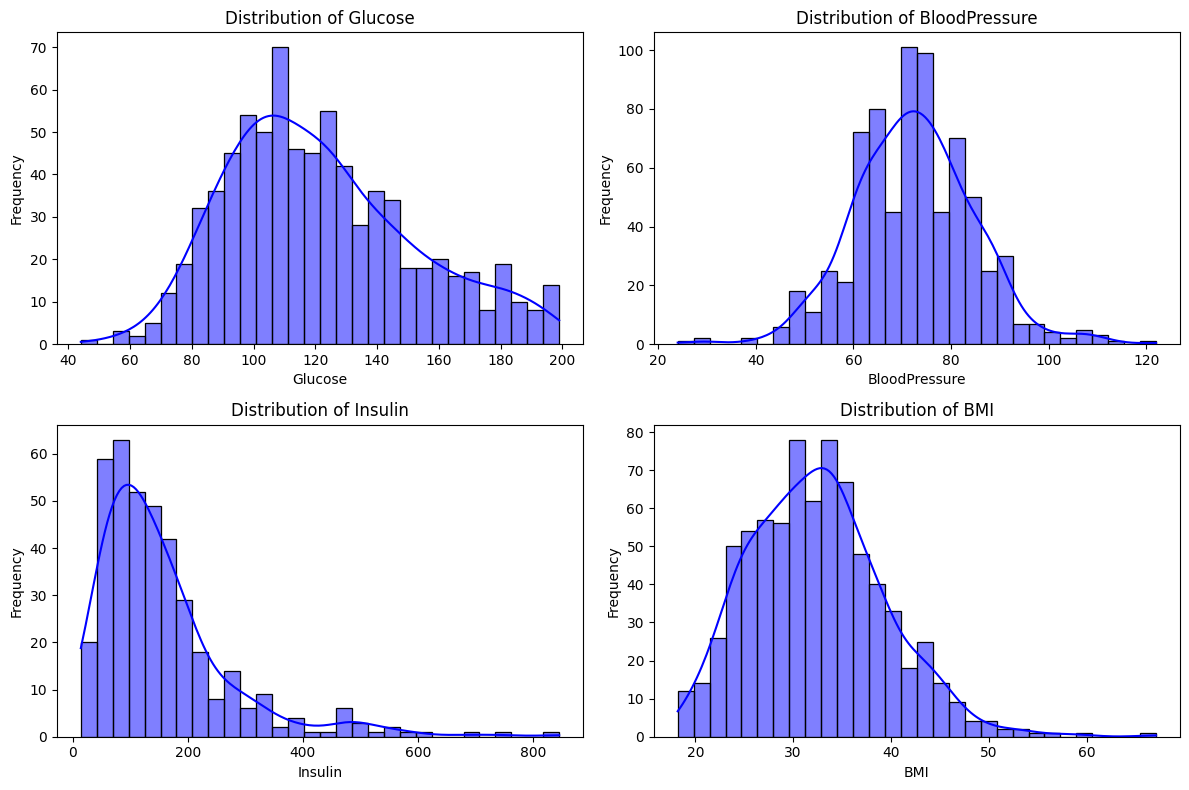

In [13]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Since the distributions are slightly skewed, I will use the median values to impute the NaNs.

In [14]:
def impute_missing_values(data, features):
    for feature in features:
        median_value = data[feature].median()
        data[feature].fillna(median_value, inplace=True)
    return data

First, I will split the data into training and test sets, and then perform imputation to avoid data leakage. I will use 30% of the data to test the model.

In [15]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Fill missing values for train and test sets

In [16]:
X_train = impute_missing_values(X_train, features)
X_test = impute_missing_values(X_test, features)

<ipython-input-14-510fba1b5587>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[feature].fillna(median_value, inplace=True)


Visualize distribution of 0 and 1 in target feature to check the data balance

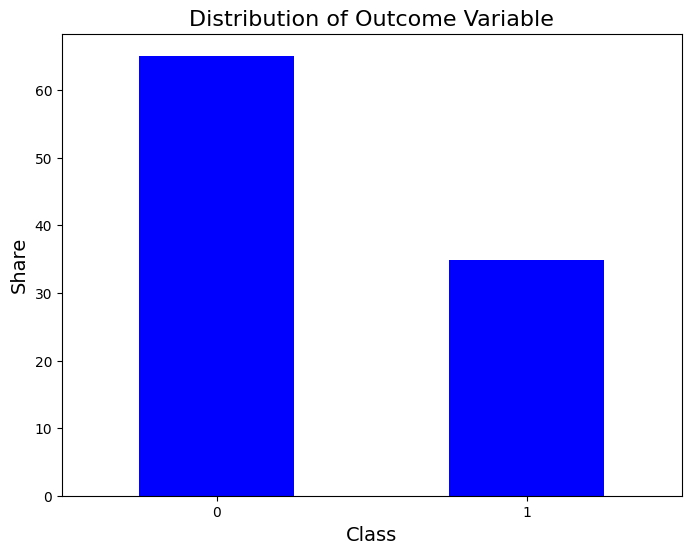

In [17]:
class_percentages = data['Outcome'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 6))
class_percentages.plot(kind='bar', color=['blue', 'blue'])
plt.title('Distribution of Outcome Variable', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Share', fontsize=14)
plt.xticks(rotation=0)
plt.show()

Our dataset is slightly imbalanced that means that 0.5 might not be the optimal threshold

To choose the optimal threshold, we need to incorporate domain knowledge, such as understanding whether false positives and false negatives are equally important. For instance, in some domains, minimizing FN is critical, while in others, reducing FP is more important. Based on similar information, we can decide what metric to prioritize.

I prefer to standardize the data because scaling helps gradient descent algorithms converge more quickly. Additionally, scaling prevents features with larger ranges from dominating those with smaller ranges. This ensures that all features contribute equally to the model's learning process, which is crucial for maintaining a balanced impact during training.

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

Convert to torch tensors

In [19]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

Build the Neural Network

In [20]:
class DiabetesPredictor(nn.Module):
    def __init__(self):
        super(DiabetesPredictor, self).__init__()
        self.fc1 = nn.Linear(in_features=8, out_features=16)
        self.fc2 = nn.Linear(in_features=16, out_features=32)
        self.fc3 = nn.Linear(in_features=32, out_features=64)
        self.fc4 = nn.Linear(in_features=64, out_features=32)
        self.fc5 = nn.Linear(in_features=32, out_features=16)
        self.fc6 = nn.Linear(in_features=16, out_features=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        x = self.relu(self.fc6(x))
        x = self.sigmoid(x)
        return x

The network has six fully connected layers with varying numbers of neurons. ReLU is used as the activation function in the hidden layers to introduce non-linearity, while the final layer uses a sigmoid function to output a probability score for the binary prediction.

Model evaluation

In [21]:
def evaluate_model(model, X, y, threshold=0.5):
    model.eval()
    with torch.no_grad():
        outputs = model(X).flatten()
        predictions = (outputs >= threshold).float()

    outputs = outputs.cpu().numpy()
    predictions = predictions.cpu().numpy()
    y = y.cpu().numpy()

    accuracy = accuracy_score(y, predictions)
    f1 = f1_score(y, predictions)

    fpr, tpr, _ = roc_curve(y, outputs)
    auc = roc_auc_score(y, outputs)

    return accuracy, f1, fpr, tpr, auc

This function evaluates a binary classification model by calculating metrics such as accuracy, F1-score, and AUC-ROC. I believe that these metrics are very important to correctly evaluate model because accuracy measures the overall correctness of predictions, while the F1-score provides a balance between precision and recall, particularly important for imbalanced datasets and AUC-ROC evaluates the model's ability to distinguish between classes at various thresholds.

Train the model

In [22]:
def train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test, num_epochs):
    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        train_loss = criterion(outputs, y_train)
        train_loss.backward()
        optimizer.step()
        train_losses.append(train_loss.item())

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses.append(test_loss.item())

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

    return train_losses, test_losses

In [23]:
model = DiabetesPredictor()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, test_losses = train_model(
    model,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    num_epochs=30
)

Epoch 1/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 2/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 3/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 4/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 5/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 6/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 7/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 8/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 9/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 10/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 11/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 12/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 13/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 14/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 15/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 16/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 17/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 18/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 19/30, Train Loss: 0.6931, Test Loss: 0.6931
Epoch 20/30, Train Loss: 0.6931, Test Lo

I set the binary cross-entropy loss function and used the Adam optimizer with a learning rate of 0.001. Then trained the model for 30 epochs and tracked the training and test losses.

Let's evaluate the model's performance


Training Performance:
Accuracy: 0.3501, F1 Score: 0.5186, AUC: 0.5000

Testing Performance:
Accuracy: 0.3463, F1 Score: 0.5145, AUC: 0.5000


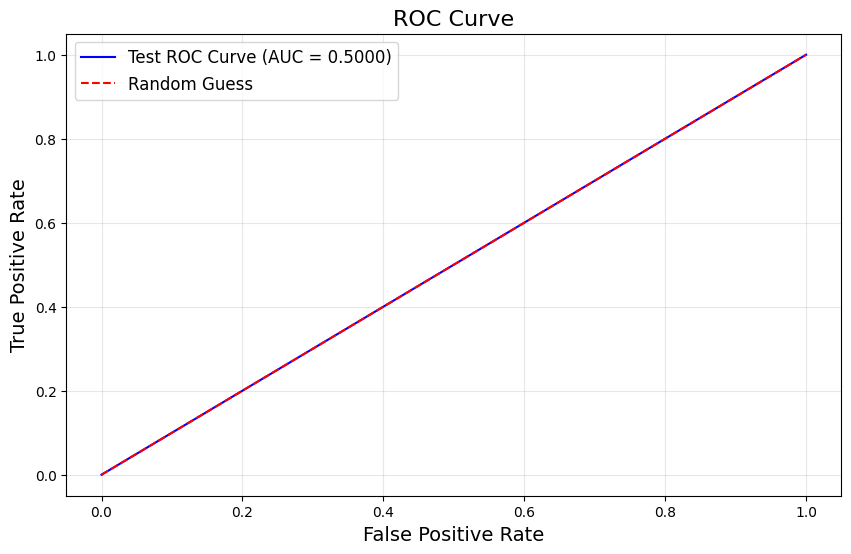

In [24]:
train_accuracy, train_f1, train_fpr, train_tpr, train_auc = evaluate_model(model, X_train, y_train)
test_accuracy, test_f1, test_fpr, test_tpr, test_auc = evaluate_model(model, X_test, y_test)

print("\nTraining Performance:")
print(f"Accuracy: {train_accuracy:.4f}, F1 Score: {train_f1:.4f}, AUC: {train_auc:.4f}")

print("\nTesting Performance:")
print(f"Accuracy: {test_accuracy:.4f}, F1 Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(test_fpr, test_tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.title('ROC Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Results are not sufficient, therefore, I will try to improve the model by adjusting some parameters and if necessary add more layers.

Let's increase number of epochs and lower learning rate

In [25]:
model = DiabetesPredictor()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
train_losses, test_losses = train_model(
    model,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    num_epochs=60
)

Epoch 1/60, Train Loss: 0.7394, Test Loss: 0.7402
Epoch 2/60, Train Loss: 0.7392, Test Loss: 0.7399
Epoch 3/60, Train Loss: 0.7389, Test Loss: 0.7397
Epoch 4/60, Train Loss: 0.7387, Test Loss: 0.7395
Epoch 5/60, Train Loss: 0.7385, Test Loss: 0.7393
Epoch 6/60, Train Loss: 0.7383, Test Loss: 0.7391
Epoch 7/60, Train Loss: 0.7381, Test Loss: 0.7389
Epoch 8/60, Train Loss: 0.7379, Test Loss: 0.7387
Epoch 9/60, Train Loss: 0.7377, Test Loss: 0.7385
Epoch 10/60, Train Loss: 0.7375, Test Loss: 0.7383
Epoch 11/60, Train Loss: 0.7373, Test Loss: 0.7380
Epoch 12/60, Train Loss: 0.7371, Test Loss: 0.7378
Epoch 13/60, Train Loss: 0.7369, Test Loss: 0.7376
Epoch 14/60, Train Loss: 0.7367, Test Loss: 0.7375
Epoch 15/60, Train Loss: 0.7365, Test Loss: 0.7373
Epoch 16/60, Train Loss: 0.7363, Test Loss: 0.7371
Epoch 17/60, Train Loss: 0.7361, Test Loss: 0.7369
Epoch 18/60, Train Loss: 0.7359, Test Loss: 0.7367
Epoch 19/60, Train Loss: 0.7357, Test Loss: 0.7365
Epoch 20/60, Train Loss: 0.7355, Test Lo


Training Performance:
Accuracy: 0.3501, F1 Score: 0.5186, AUC: 0.5610

Testing Performance:
Accuracy: 0.3463, F1 Score: 0.5145, AUC: 0.5019


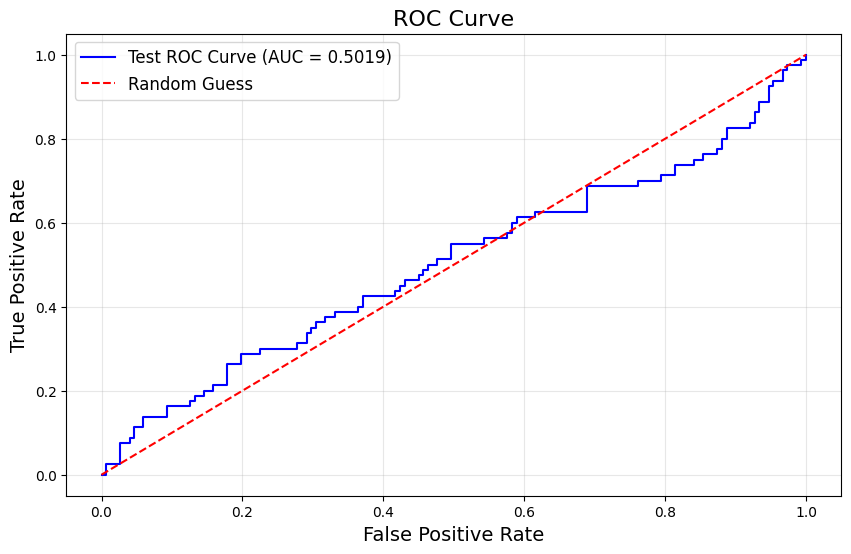

In [26]:
train_accuracy, train_f1, train_fpr, train_tpr, train_auc = evaluate_model(model, X_train, y_train)
test_accuracy, test_f1, test_fpr, test_tpr, test_auc = evaluate_model(model, X_test, y_test)

print("\nTraining Performance:")
print(f"Accuracy: {train_accuracy:.4f}, F1 Score: {train_f1:.4f}, AUC: {train_auc:.4f}")

print("\nTesting Performance:")
print(f"Accuracy: {test_accuracy:.4f}, F1 Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(test_fpr, test_tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.title('ROC Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Did not improve model's performance, therefore I will try different setup.

In [27]:
class DiabetesPredictor(nn.Module):
    def __init__(self):
        super(DiabetesPredictor, self).__init__()
        self.fc1 = nn.Linear(in_features=8, out_features=64)
        self.fc2 = nn.Linear(in_features=64, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=256)
        self.fc4 = nn.Linear(in_features=256, out_features=128)
        self.fc5 = nn.Linear(in_features=128, out_features=64)
        self.fc6 = nn.Linear(in_features=64, out_features=1)

        self.dropout = nn.Dropout(p=0.5)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.dropout(x)
        x = self.relu(self.fc5(x))
        x = self.dropout(x)
        x = self.fc6(x)
        x = self.sigmoid(x)
        return x

I increased the model complexity by adding more layers with larger numbers of neurons to enable the network to learn more complex patterns in the data. I also introduced dropout layers after each hidden layer to prevent overfitting. These changes aim to improve model performance while reducing the risk of overfitting by controlling the complexity and regularizing the training process.

In [28]:
model = DiabetesPredictor()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, test_losses = train_model(
    model,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    num_epochs=35
)

Epoch 1/35, Train Loss: 0.7079, Test Loss: 0.7053
Epoch 2/35, Train Loss: 0.7043, Test Loss: 0.7024
Epoch 3/35, Train Loss: 0.7013, Test Loss: 0.6993
Epoch 4/35, Train Loss: 0.6964, Test Loss: 0.6959
Epoch 5/35, Train Loss: 0.6931, Test Loss: 0.6920
Epoch 6/35, Train Loss: 0.6887, Test Loss: 0.6875
Epoch 7/35, Train Loss: 0.6818, Test Loss: 0.6821
Epoch 8/35, Train Loss: 0.6756, Test Loss: 0.6757
Epoch 9/35, Train Loss: 0.6715, Test Loss: 0.6683
Epoch 10/35, Train Loss: 0.6611, Test Loss: 0.6598
Epoch 11/35, Train Loss: 0.6573, Test Loss: 0.6504
Epoch 12/35, Train Loss: 0.6565, Test Loss: 0.6409
Epoch 13/35, Train Loss: 0.6446, Test Loss: 0.6313
Epoch 14/35, Train Loss: 0.6434, Test Loss: 0.6225
Epoch 15/35, Train Loss: 0.6266, Test Loss: 0.6143
Epoch 16/35, Train Loss: 0.6198, Test Loss: 0.6070
Epoch 17/35, Train Loss: 0.6291, Test Loss: 0.6006
Epoch 18/35, Train Loss: 0.6290, Test Loss: 0.5950
Epoch 19/35, Train Loss: 0.6128, Test Loss: 0.5899
Epoch 20/35, Train Loss: 0.6154, Test Lo


Training Performance:
Accuracy: 0.7598, F1 Score: 0.5879, AUC: 0.8505

Testing Performance:
Accuracy: 0.7316, F1 Score: 0.5373, AUC: 0.7847


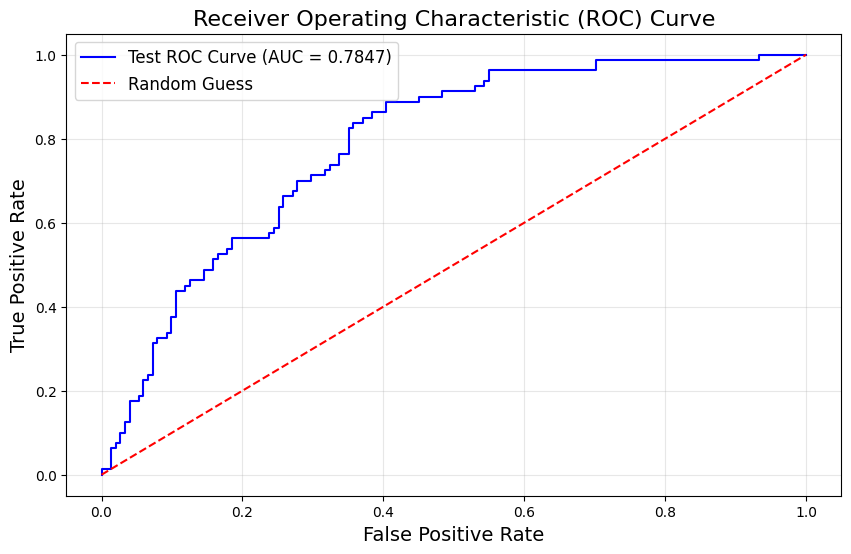

In [29]:
train_accuracy, train_f1, train_fpr, train_tpr, train_auc = evaluate_model(model, X_train, y_train)
test_accuracy, test_f1, test_fpr, test_tpr, test_auc = evaluate_model(model, X_test, y_test)

print("\nTraining Performance:")
print(f"Accuracy: {train_accuracy:.4f}, F1 Score: {train_f1:.4f}, AUC: {train_auc:.4f}")

print("\nTesting Performance:")
print(f"Accuracy: {test_accuracy:.4f}, F1 Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(test_fpr, test_tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

The new model setup shows reasonable improvements. I tried different learning rates and numbers of epochs, selecting the configuration that showed good and consistent performance across both the training and test sets.

I want to test different activation functions as well to find which one performs best for our binary classification task, and redefine the training function to include early stopping, learning rate scheduling, and gradient clipping for more effective training.

In [30]:
class DiabetesPredictor(nn.Module):
    def __init__(self):
        super(DiabetesPredictor, self).__init__()
        self.fc1 = nn.Linear(8, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.fc4 = nn.Linear(16, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        x = self.sigmoid(self.fc4(x))
        return x

The new model incorporates batch normalization after each hidden layer to stabilize and speed up training by normalizing activations. Dropout is added after each ReLU activation to reduce overfitting by randomly setting some neuron outputs to zero during training. Xavier initialization is used for the weights, ensuring proper scaling of parameters to avoid vanishing or exploding gradients. These changes improve the model’s ability to generalize, prevent overfitting, and accelerate convergence, potentially leading to better performance on both the training and test sets.

In [31]:
def train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test, num_epochs):
    train_losses = []
    test_losses = []

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    best_loss = float('inf')
    no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        train_loss = criterion(outputs, y_train)
        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            scheduler.step(test_loss)

            if test_loss < best_loss:
                best_loss = test_loss
                no_improve = 0
            else:
                no_improve += 1

            if no_improve > 10:
                print(f"Early stopping at epoch {epoch}")
                break

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

    return train_losses, test_losses

This updated training function introduces a learning rate scheduler to reduce the learning rate when the test loss plateaus, helping the model converge more efficiently. Gradient clipping is applied to prevent exploding gradients by limiting the maximum gradient norm to 1.0. Early stopping is implemented again to halt training if the test loss does not improve for 10 consecutive epochs

In [32]:
model = DiabetesPredictor()
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])
criterion = nn.BCELoss(weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)
train_losses, test_losses = train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test, num_epochs=50)

Epoch 1/50, Train Loss: 1.5381, Test Loss: 1.2611
Epoch 2/50, Train Loss: 1.3169, Test Loss: 1.2322
Epoch 3/50, Train Loss: 1.1739, Test Loss: 1.1998
Epoch 4/50, Train Loss: 1.1099, Test Loss: 1.1624
Epoch 5/50, Train Loss: 1.0619, Test Loss: 1.1252
Epoch 6/50, Train Loss: 1.0675, Test Loss: 1.0888
Epoch 7/50, Train Loss: 0.9968, Test Loss: 1.0533
Epoch 8/50, Train Loss: 1.0112, Test Loss: 1.0218
Epoch 9/50, Train Loss: 0.9327, Test Loss: 0.9954
Epoch 10/50, Train Loss: 0.9206, Test Loss: 0.9744
Epoch 11/50, Train Loss: 0.9530, Test Loss: 0.9583
Epoch 12/50, Train Loss: 0.9120, Test Loss: 0.9482
Epoch 13/50, Train Loss: 0.8912, Test Loss: 0.9430
Epoch 14/50, Train Loss: 0.8978, Test Loss: 0.9434
Epoch 15/50, Train Loss: 0.8727, Test Loss: 0.9474
Epoch 16/50, Train Loss: 0.8422, Test Loss: 0.9545
Epoch 17/50, Train Loss: 0.8555, Test Loss: 0.9633
Epoch 18/50, Train Loss: 0.8674, Test Loss: 0.9736
Epoch 19/50, Train Loss: 0.8412, Test Loss: 0.9867
Epoch 20/50, Train Loss: 0.8503, Test Lo


Training Performance:
Accuracy: 0.7970, F1 Score: 0.6877, AUC: 0.8836

Testing Performance:
Accuracy: 0.7619, F1 Score: 0.6452, AUC: 0.8092


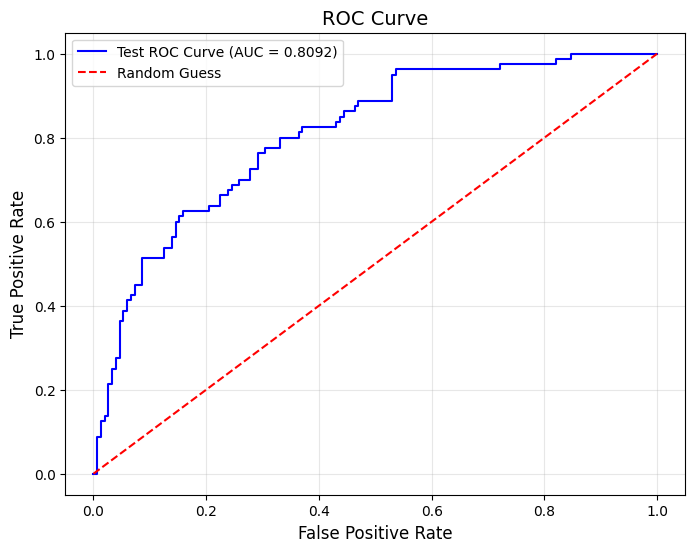

In [33]:
train_accuracy, train_f1, train_fpr, train_tpr, train_auc = evaluate_model(model, X_train, y_train)
test_accuracy, test_f1, test_fpr, test_tpr, test_auc = evaluate_model(model, X_test, y_test)

print("\nTraining Performance:")
print(f"Accuracy: {train_accuracy:.4f}, F1 Score: {train_f1:.4f}, AUC: {train_auc:.4f}")

print("\nTesting Performance:")
print(f"Accuracy: {test_accuracy:.4f}, F1 Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.title('ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

I think this model is the best one so far.

Let's build pytorch lightning training scripts

In [34]:
class DiabetesDataModule(pl.LightningDataModule):
    def __init__(self, X_train, X_test, y_train, y_test, batch_size=32):
        super().__init__()
        self.batch_size = batch_size
        self.X_train = torch.FloatTensor(X_train)
        self.y_train = torch.FloatTensor(y_train)
        self.X_test = torch.FloatTensor(X_test)
        self.y_test = torch.FloatTensor(y_test)

    def train_dataloader(self):
        train_dataset = TensorDataset(self.X_train, self.y_train)
        return DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        val_dataset = TensorDataset(self.X_test, self.y_test)
        return DataLoader(val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        test_dataset = TensorDataset(self.X_test, self.y_test)
        return DataLoader(test_dataset, batch_size=self.batch_size)

In [35]:
class DiabetesPredictor(pl.LightningModule):
    def __init__(self, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        self.network = nn.Sequential(
            nn.Linear(8, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

        for m in self.network.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        self.predictions = []
        self.targets = []

    def forward(self, x):
        return self.network(x)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(),
                                    lr=self.hparams.learning_rate,
                                    weight_decay=0.1)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.BCELoss()(y_hat, y)

        preds = (y_hat >= 0.5).float()
        y_np = y.cpu().detach().numpy()
        preds_np = preds.cpu().detach().numpy()

        acc = accuracy_score(y_np, preds_np)
        f1 = f1_score(y_np, preds_np)

        self.log('train_loss', loss)
        self.log('train_acc', acc)
        self.log('train_f1', f1)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        val_loss = nn.BCELoss()(y_hat, y)

        self.predictions.append(y_hat.cpu().detach().numpy())
        self.targets.append(y.cpu().detach().numpy())

        preds = (y_hat >= 0.5).float()
        y_np = y.cpu().detach().numpy()
        preds_np = preds.cpu().detach().numpy()

        acc = accuracy_score(y_np, preds_np)
        f1 = f1_score(y_np, preds_np)

        self.log('val_loss', val_loss)
        self.log('val_acc', acc)
        self.log('val_f1', f1)

        return val_loss

    def on_validation_epoch_end(self):
        predictions = np.concatenate([p.ravel() for p in self.predictions])
        targets = np.concatenate([t.ravel() for t in self.targets])

        if len(predictions) > 0:
            fpr, tpr, _ = roc_curve(targets, predictions)
            auc = roc_auc_score(targets, predictions)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', color='blue')
            plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
            plt.title('ROC Curve')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.close()

            self.log('val_auc', auc)

        self.predictions = []
        self.targets = []

Now train the model

In [36]:
def train_model(X_train, X_test, y_train, y_test):
    data_module = DiabetesDataModule(X_train, X_test, y_train, y_test)

    model = DiabetesPredictor()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        mode='min'
    )

    checkpoint_callback = ModelCheckpoint(
        monitor='val_loss',
        dirpath='checkpoints',
        filename='diabetes-{epoch:02d}-{val_loss:.2f}',
        save_top_k=1,
        mode='min'
    )

    logger = TensorBoardLogger("lightning_logs", name="diabetes_predictor")

    trainer = pl.Trainer(
        max_epochs=50,
        callbacks=[early_stopping, checkpoint_callback],
        logger=logger,
        accelerator='cpu',
        devices=1
    )

    trainer.fit(model, data_module)
    return model, trainer

model, trainer = train_model(X_train, X_test, y_train, y_test)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | network | Sequential | 929    | train
-----------------------------------------------
929       Trainable params
0         Non-trainable params
929       Total params
0.004     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (17) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

And finally evaluate it


Training Results:
Accuracy: 0.7914
F1 Score: 0.6686
AUC Score: 0.8717

Test Results:
Accuracy: 0.7489
F1 Score: 0.6234
AUC Score: 0.7990


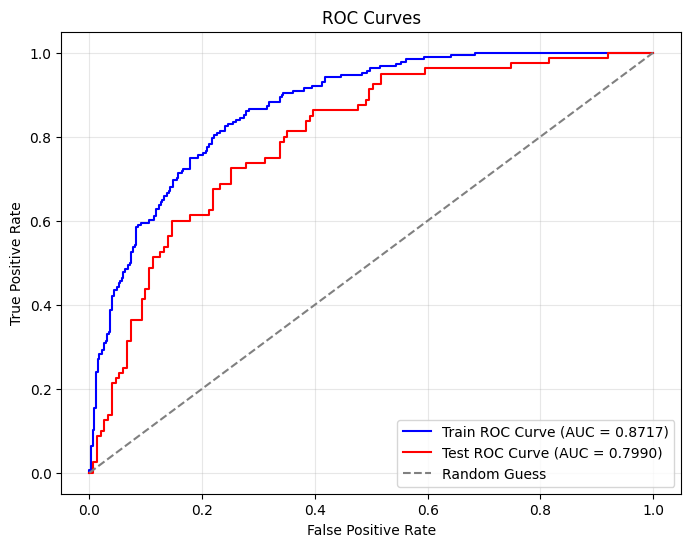

In [37]:
model.eval()
with torch.no_grad():
    train_pred = model(torch.FloatTensor(X_train))
    train_pred_binary = (train_pred >= 0.5).float()
    test_pred = model(torch.FloatTensor(X_test))
    test_pred_binary = (test_pred >= 0.5).float()

    train_pred_np = train_pred.cpu().detach().numpy()
    train_pred_binary_np = train_pred_binary.cpu().detach().numpy()
    y_train_np = y_train.cpu().detach().numpy()

    test_pred_np = test_pred.cpu().detach().numpy()
    test_pred_binary_np = test_pred_binary.cpu().detach().numpy()
    y_test_np = y_test.cpu().detach().numpy()

    train_accuracy = accuracy_score(y_train_np, train_pred_binary_np)
    train_f1 = f1_score(y_train_np, train_pred_binary_np)
    train_auc = roc_auc_score(y_train_np, train_pred_np)

    test_accuracy = accuracy_score(y_test_np, test_pred_binary_np)
    test_f1 = f1_score(y_test_np, test_pred_binary_np)
    test_auc = roc_auc_score(y_test_np, test_pred_np)

    print("\nTraining Results:")
    print(f"Accuracy: {train_accuracy:.4f}")
    print(f"F1 Score: {train_f1:.4f}")
    print(f"AUC Score: {train_auc:.4f}")

    print("\nTest Results:")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"AUC Score: {test_auc:.4f}")

train_fpr, train_tpr, _ = roc_curve(y_train_np, train_pred_np)
test_fpr, test_tpr, _ = roc_curve(y_test_np, test_pred_np)

plt.figure(figsize=(8, 6))
plt.plot(train_fpr, train_tpr, label=f'Train ROC Curve (AUC = {train_auc:.4f})', color='blue')
plt.plot(test_fpr, test_tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})', color='red')
plt.plot([0, 1], [0, 1], '--', label='Random Guess', color='gray')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

It is expected that the results are very similar to the performance of the previous model, because we used the same network setup. Due to random initialization and different frameworks, results are not exactly the same.

<h3 align="center">Task N2.1 - 1D Convolution operation</h3>

- **Convolution** is an operation when we have 2 functions and by merging them together we get a third function. For images, first "function" is the pixel values of the image and the second "function" is the filter itself. For 1D data(Like time-series or text) we have 1D Convolution kernels, for 2D/3D data we have appropriate kernels as well

- For time series data we can see on the below image how convolution operation is done on 1D data. It is often used for denoising the data. For example you can use an averaging kernel( 1/n, 1/n ... 1/n ) for denoising. Explain what tradeoff is between using large kernels and smaller kernels by observing the outputs.

![Image alt text](https://i.stack.imgur.com/WNIXd.png)

- Your task is to build a sliding window 1D convolution on a sine function with some noise added to it. Below you can see the code for initializing it and plotting the noisy data. Your task is to denoise the `noisy_signal` variable. Write a function which will take in the `noisy_signal` and denoise it with 1D convolution.
```
N = 1000  # Number of data points
t = np.linspace(0, 4*np.pi, N)  # Time variable
clean_signal = np.sin(t)  # Clean sin function
noise = np.random.normal(0, 0.5, N)
noisy_signal = clean_signal + noise
plt.plot(t, noisy_signal)
plt.title('Noisy Signal')
plt.show()
```

Let's generate data as described

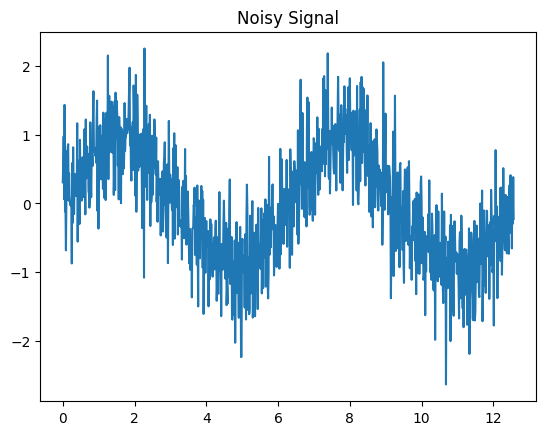

In [38]:
N = 1000
t = np.linspace(0, 4*np.pi, N)
clean_signal = np.sin(t)
noise = np.random.normal(0, 0.5, N)
noisy_signal = clean_signal + noise
plt.plot(t, noisy_signal)
plt.title('Noisy Signal')
plt.show()

Implement 1D convolution operation manually

In [39]:
def convolution_1D(signal, kernel):
    signal_len = len(signal)
    kernel_len = len(kernel)

    pad_size = kernel_len // 2
    padded_signal = np.pad(signal, (pad_size, pad_size), mode='edge')
    output = np.zeros(signal_len)

    for i in range(signal_len):
        output[i] = np.sum(padded_signal[i:i + kernel_len] * kernel)

    return output

Define different kernel sizes and then evaluate their corresponding results

In [40]:
kernel_sizes = [3, 5, 10, 15, 20]

Try different kernel sizes and plot results

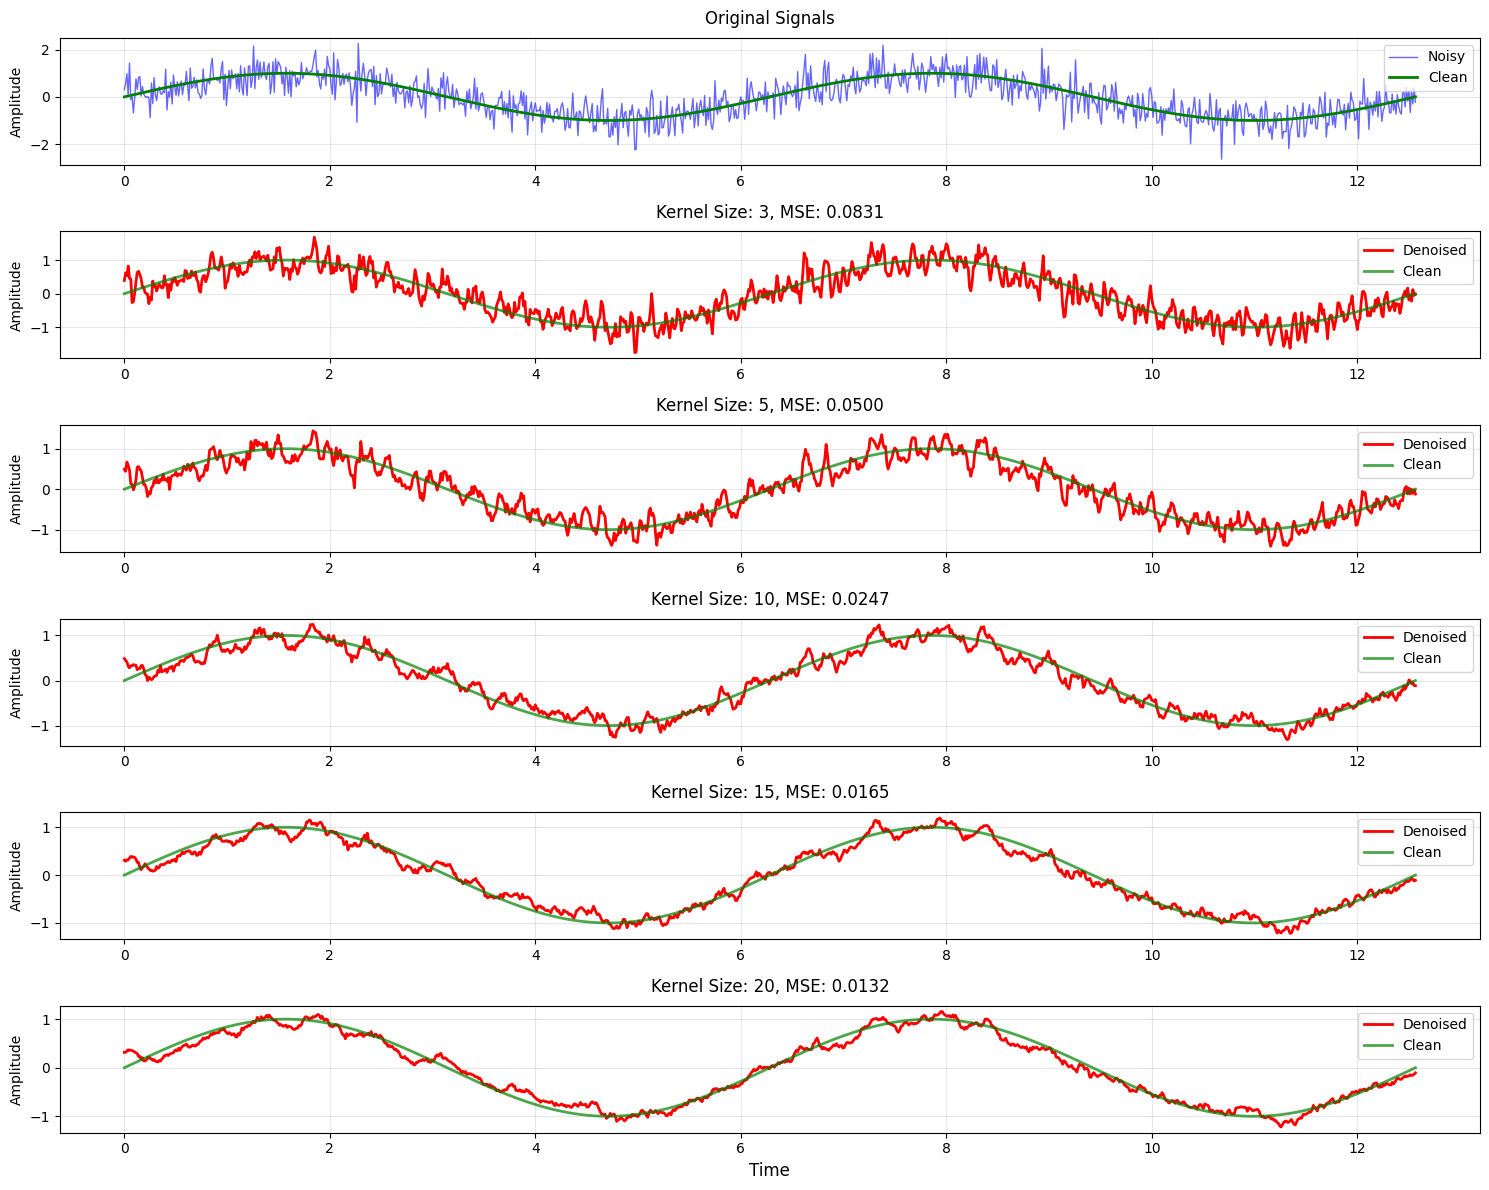

In [41]:
plt.figure(figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)
plt.subplot(len(kernel_sizes) + 1, 1, 1)
plt.plot(t, noisy_signal, 'b-', label='Noisy', linewidth=1, alpha=0.6)
plt.plot(t, clean_signal, 'g-', label='Clean', linewidth=2)
plt.legend(fontsize=10, loc='upper right')
plt.title('Original Signals', fontsize=12, pad=10)
plt.grid(True, alpha=0.3)
plt.ylabel('Amplitude')
for idx, size in enumerate(kernel_sizes, 1):
    kernel = np.ones(size) / size
    denoised = convolution_1D(noisy_signal, kernel)
    mse = np.mean((clean_signal - denoised)**2)

    plt.subplot(len(kernel_sizes) + 1, 1, idx + 1)
    plt.plot(t, denoised, 'r-', label=f'Denoised', linewidth=2)
    plt.plot(t, clean_signal, 'g-', label='Clean', linewidth=2, alpha=0.7)
    plt.legend(fontsize=10, loc='upper right')
    plt.title(f'Kernel Size: {size}, MSE: {mse:.4f}', fontsize=12, pad=10)
    plt.grid(True, alpha=0.3)
    plt.ylabel('Amplitude')

plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.show()

Choosing the right kernel size is all about balancing noise reduction and keeping the original signal intact. Smaller kernels, like size 3 or 5, do a better job at preserving the sharp changes and details in the signal. However, they aren’t as effective at removing noise, which is why their MSE values are higher. On the other hand, larger kernels, like size 15 or 20, are great at smoothing out the noise and have lower MSE values. But they also tend to blur the signal and make peaks and valleys less pronounced. You can see this in the plots – with a kernel size of 20, the line is the smoothest and has the lowest MSE (0.0118), but the sine wave’s peaks and dips are slightly reduced. The best kernel size depends on what matters more for the task – keeping the details or reducing the noise.

<h3 align="center">Task N2.2 - 2D Convolution operation</h3>

- In image processing **Convolution** filter/kernel is a $k \times k$ matrix which is used for retrieving useful features from the image. It is a fundamental building block of Convolutional neural networks(CNN)

- After applying the kernel over the image, we often get a downsampled feature map from the image as shown in the animation below:
  
<center><img src="https://drive.google.com/uc?export=view&id=153Aj-MSmLndc3dNhl9HvbpNZhDGlYB_I" alt="Example" /></center>


- Your job is to write a convolution operation as a function(without using packages like torch,tensorflow, keras etc.) which takes in image of shape (**CxHxW**, C - Channel(usually RGB), H - Height of the image, W - Width of the image) and get the output image after applying convolution like it's shown in the illustration. Keep dimensions of the image in mind, if kernel is larger than the image, 28x28 image let's say and user inputs kernel size of 30x30, then return an error. Implementing padding in this task is not needed.

- For testing the output you can use the **uniform blur** kernel for any image you like which is defined below:
  \begin{equation}
K = \frac{1}{9} \begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
\end{equation}

- Try your function on grayscale images with Sobel Operator and explain the output:
\begin{equation}
K = \begin{bmatrix}
-1 & 0 &  1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
\end{equation}

First implement 2D convolution operation function manually

In [42]:
def convolution_2D(image, kernel):
    if len(image.shape) == 2:
        image = image[np.newaxis, :, :]

    C, H, W = image.shape
    k = kernel.shape[0]

    out_h = H - k + 1
    out_w = W - k + 1

    output = np.zeros((C, out_h, out_w))

    for c in range(C):
        for i in range(out_h):
            for j in range(out_w):
                patch = image[c, i:i+k, j:j+k]
                output[c, i, j] = np.sum(patch * kernel)

    return output

Use helper function to load images to test later

In [43]:
def load_and_preprocess_image(path, size=None, grayscale=False):
    img = Image.open(path)
    if size:
        img = img.resize(size)
    if grayscale:
        img = img.convert('L')
        return np.array(img)
    img = np.array(img).transpose(2, 0, 1)
    return img / 255.0

This function preprocesses images by normalizing RGB values to a [0, 1] range and rearranging the axes into the format C, H, W that is suitable for model training. It also includes resizing and grayscale conversion if needed.

Helper function to visualize results

In [44]:
def visualize_results(original, processed, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(121)
    if len(original.shape) == 3:
        plt.imshow(original.transpose(1, 2, 0))
    else:
        plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    if len(processed.shape) == 3:
        plt.imshow(processed.transpose(1, 2, 0))
    else:
        plt.imshow(processed[0], cmap='gray')
    plt.title(title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Test with RGB image, use uniform blur kernel

In [45]:
blur_kernel = np.ones((3, 3)) / 9

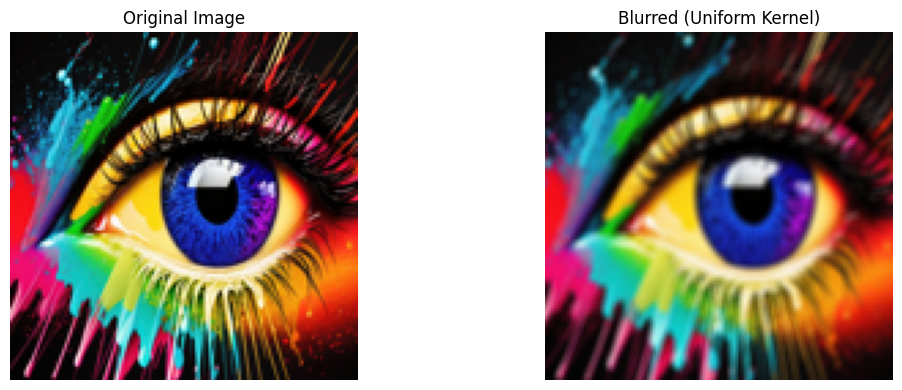

In [46]:
img_rgb = load_and_preprocess_image('/content/1692207203650.jpg', size=(128, 128))
blurred_rgb = convolution_2D(img_rgb, blur_kernel)
visualize_results(img_rgb, blurred_rgb, 'Blurred (Uniform Kernel)')

Using the uniform kernel makes the image look smoother by averaging the colors of nearby pixels in a small 3x3 area. This helps to reduce noise but also removes some of the sharp details and edges in the image. As a result, the image looks softer and less detailed compared to the original.

Test with grayscale image and Sobel operator

In [47]:
sobel_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

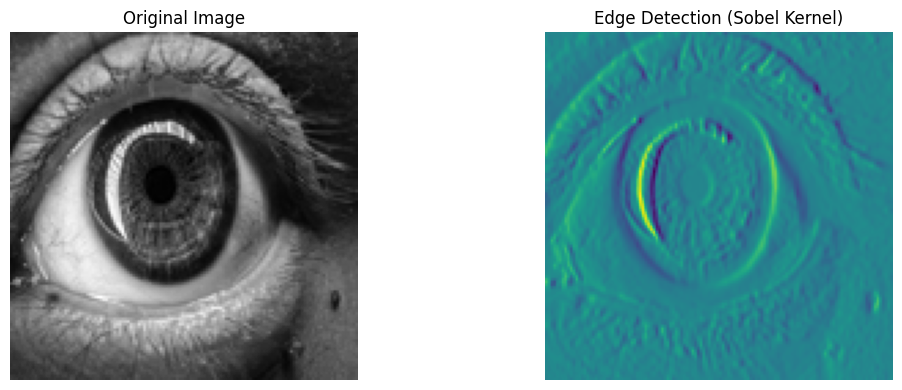

In [48]:
img_gray = load_and_preprocess_image('/content/pexels-photo-13477136.jpeg', size=(128, 128), grayscale=True)
edges = convolution_2D(img_gray, sobel_kernel)
visualize_results(img_gray, edges, 'Edge Detection (Sobel Kernel)')

The Sobel kernel is great for finding edges in an image by spotting areas where the brightness changes a lot. In the edge detection result, we can clearly see the outlines of the eye and other important parts of the image. However, it doesn’t show smooth areas or textures, so it’s better for highlighting shapes rather than showing full details of the image.